In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
from statistics import mean,median,mode

In [5]:
df=pd.read_csv("C:\\Users\\sweth\\Downloads\\archive (2)\\sales_data.csv")
df.head()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022-01-01,S001,P0001,Electronics,North,195,102,252,72.72,5,Snowy,0,85.73,Winter,0,115
1,2022-01-01,S001,P0002,Clothing,North,117,117,249,80.16,15,Snowy,1,92.02,Winter,0,229
2,2022-01-01,S001,P0003,Clothing,North,247,114,612,62.94,10,Snowy,1,60.08,Winter,0,157
3,2022-01-01,S001,P0004,Electronics,North,139,45,102,87.63,10,Snowy,0,85.19,Winter,0,52
4,2022-01-01,S001,P0005,Groceries,North,152,65,271,54.41,0,Snowy,0,51.63,Winter,0,59


In [6]:
df.tail()

,Date,Store ID,Product ID,Category,Region,Inventory Level,Units Sold,Units Ordered,Price,Discount,Weather Condition,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
75995,2024-01-30,S005,P0016,Toys,North,233,63,0,29.80,5,Snowy,0,32.23,Winter,0,64
75996,2024-01-30,S005,P0017,Toys,North,137,115,141,42.92,5,Snowy,0,40.73,Winter,0,137
75997,2024-01-30,S005,P0018,Clothing,North,197,44,0,17.81,10,Snowy,0,19.41,Winter,0,68
75998,2024-01-30,S005,P0019,Furniture,North,125,58,0,151.72,0,Snowy,0,143.71,Winter,0,84
75999,2024-01-30,S005,P0020,Toys,North,126,63,59,25.78,10,Snowy,0,29.32,Winter,0,73


In [7]:
df.shape

(76000, 16)

In [8]:
df.isnull().sum()

Date                  0
Store ID              0
Product ID            0
Category              0
Region                0
Inventory Level       0
Units Sold            0
Units Ordered         0
Price                 0
Discount              0
Weather Condition     0
Promotion             0
Competitor Pricing    0
Seasonality           0
Epidemic              0
Demand                0
dtype: int64

In [9]:
df.dtypes

Date                      str
Store ID                  str
Product ID                str
Category                  str
Region                    str
Inventory Level         int64
Units Sold              int64
Units Ordered           int64
Price                 float64
Discount                int64
Weather Condition         str
Promotion               int64
Competitor Pricing    float64
Seasonality               str
Epidemic                int64
Demand                  int64
dtype: object

In [10]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 76000 entries, 0 to 75999
Data columns (total 16 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Date                76000 non-null  str    
 1   Store ID            76000 non-null  str    
 2   Product ID          76000 non-null  str    
 3   Category            76000 non-null  str    
 4   Region              76000 non-null  str    
 5   Inventory Level     76000 non-null  int64  
 6   Units Sold          76000 non-null  int64  
 7   Units Ordered       76000 non-null  int64  
 8   Price               76000 non-null  float64
 9   Discount            76000 non-null  int64  
 10  Weather Condition   76000 non-null  str    
 11  Promotion           76000 non-null  int64  
 12  Competitor Pricing  76000 non-null  float64
 13  Seasonality         76000 non-null  str    
 14  Epidemic            76000 non-null  int64  
 15  Demand              76000 non-null  int64  
dtypes: float64(2), 

In [11]:
df.describe()

,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Epidemic,Demand
count,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000,76000.000000
mean,301.062842,88.827316,89.090645,67.726028,9.087039,0.328947,69.454029,0.200000,104.317158
std,226.510161,43.994525,162.404627,39.377899,7.475781,0.469834,40.943818,0.400003,46.964801
min,0.000000,0.000000,0.000000,4.740000,0.000000,0.000000,4.290000,0.000000,4.000000
25%,136.000000,58.000000,0.000000,31.997500,5.000000,0.000000,32.620000,0.000000,71.000000
50%,227.000000,84.000000,0.000000,64.500000,10.000000,0.000000,65.700000,0.000000,100.000000
75%,408.000000,114.000000,121.000000,95.830000,10.000000,1.000000,97.932500,0.000000,133.000000
max,2267.000000,426.000000,1616.000000,228.030000,25.000000,1.000000,261.220000,1.000000,430.000000


<Axes: >

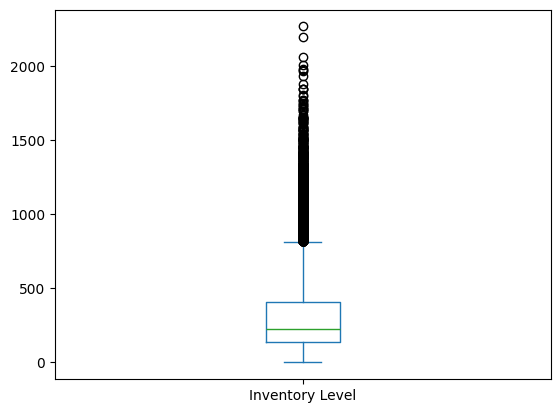

In [12]:
#finding outliers
df['Inventory Level'].plot(kind='box')

<Axes: >

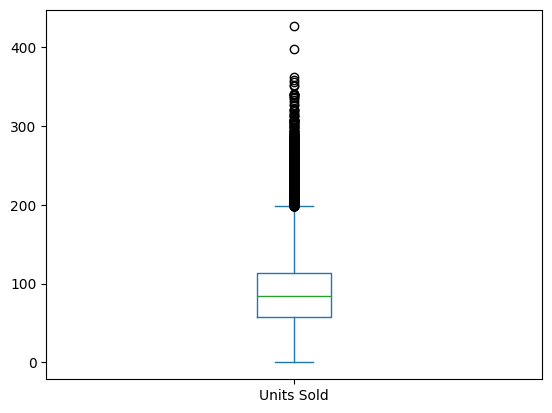

In [13]:
df['Units Sold'].plot(kind='box')

<Axes: >

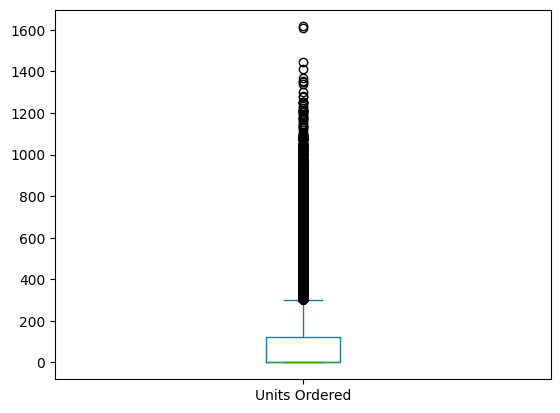

In [14]:
df['Units Ordered'].plot(kind='box')

<Axes: >

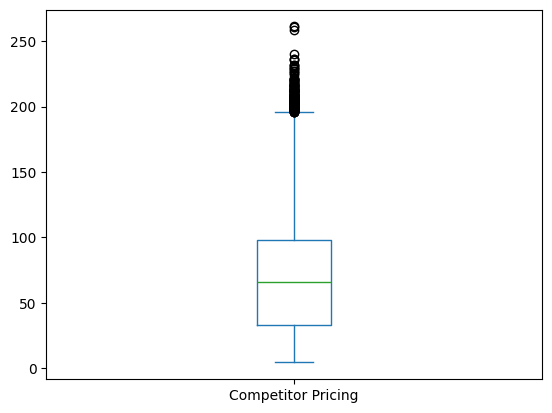

In [15]:
df['Competitor Pricing'].plot(kind='box')


Upper limit for IL: 798.04
Outliers removed


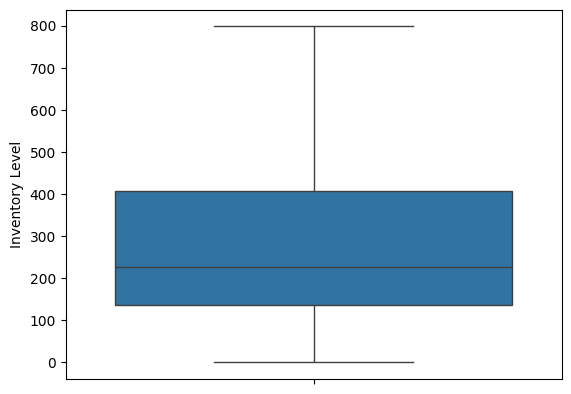

In [16]:
#handeling outliers
upper_limit_inventoryl=df['Inventory Level'].quantile(0.96)
print(f"\nUpper limit for IL: {upper_limit_inventoryl:.2f}")
df['Inventory Level']=np.where(df['Inventory Level']>upper_limit_inventoryl,upper_limit_inventoryl,df['Inventory Level'])
print('Outliers removed')
sns.boxplot(y=df['Inventory Level'])
plt.show()


Upper limit for us: 146.00
Outliers removed


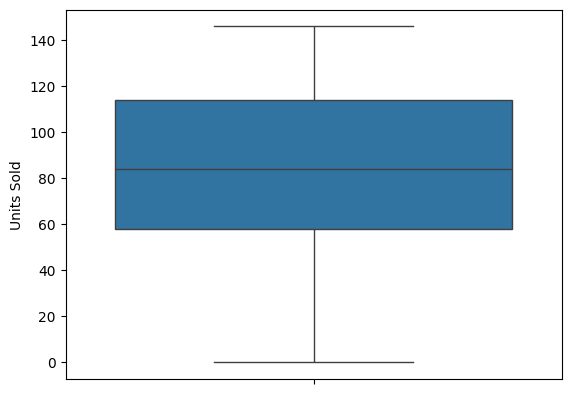

In [17]:
upper_limit_us=df['Units Sold'].quantile(0.90)
print(f"\nUpper limit for us: {upper_limit_us:.2f}")
df['Units Sold']=np.where(df['Units Sold']>upper_limit_us,upper_limit_us,df['Units Sold'])
print('Outliers removed')
sns.boxplot(y=df['Units Sold'])
plt.show()


Upper limit for uo: 300.00
Outliers removed


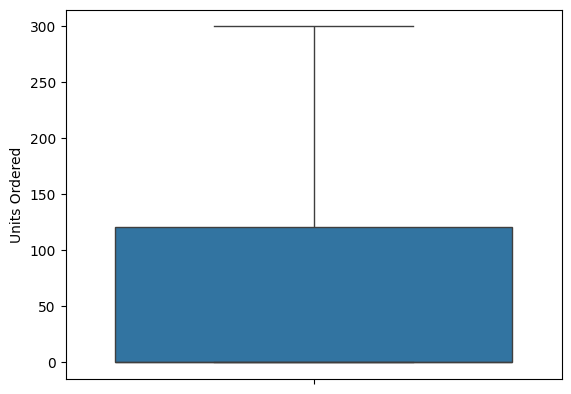

In [18]:
upper_limit_uo=df['Units Ordered'].quantile(0.90)
print(f"\nUpper limit for uo: {upper_limit_uo:.2f}")
df['Units Ordered']=np.where(df['Units Ordered']>upper_limit_uo,upper_limit_uo,df['Units Ordered'])
print('Outliers removed')
sns.boxplot(df['Units Ordered'])
plt.show()


Upper limit for cp: 174.83
Outliers removed


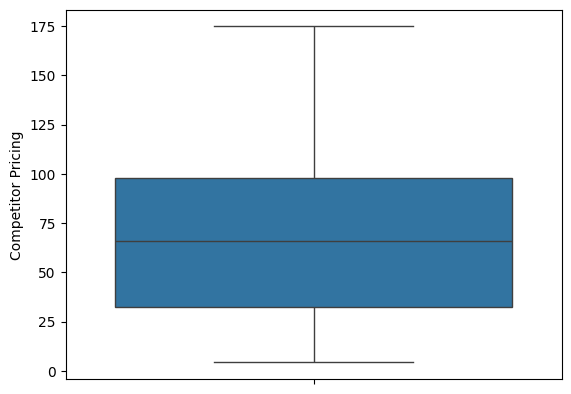

In [19]:
upper_limit_cp=df['Competitor Pricing'].quantile(0.99)
print(f"\nUpper limit for cp: {upper_limit_cp:.2f}")
df['Competitor Pricing']=np.where(df['Competitor Pricing']>upper_limit_cp,upper_limit_cp,df['Competitor Pricing'])
print('Outliers removed')
sns.boxplot(df['Competitor Pricing'])
plt.show()

<Axes: >

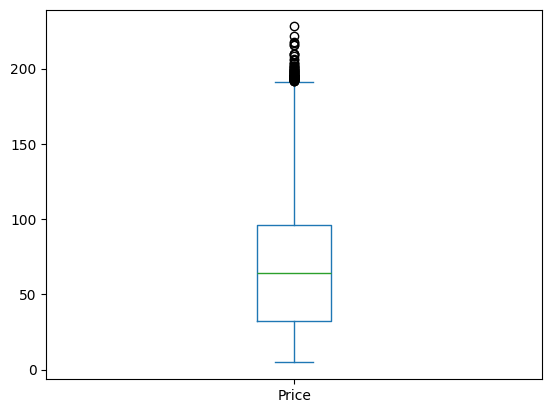

In [20]:
df['Price'].plot(kind='box')


Upper limit for price: 121.92
Outliers removed


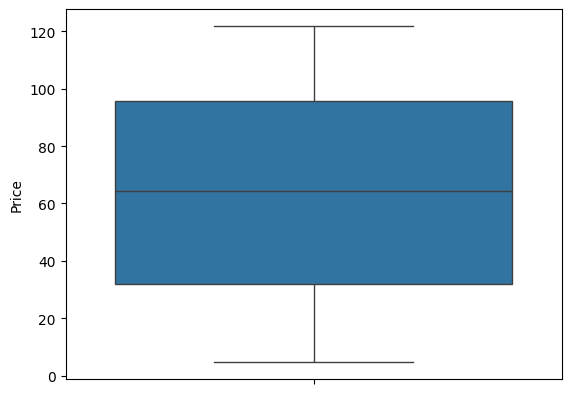

In [21]:
upper_limit_price=df['Price'].quantile(0.90)
print(f"\nUpper limit for price: {upper_limit_price:.2f}")
df['Price']=np.where(df['Price']>upper_limit_price,upper_limit_price,df['Price'])
print('Outliers removed')
sns.boxplot(df['Price'])
plt.show()

<Axes: >

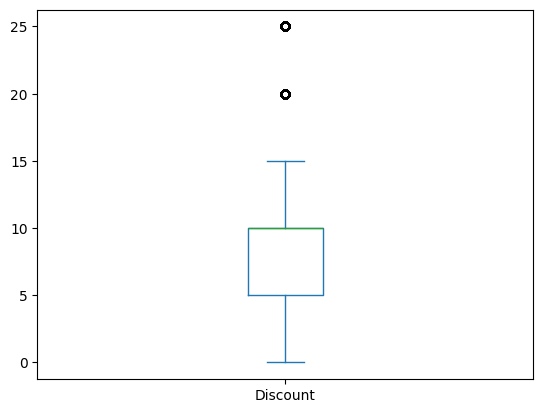

In [22]:
df['Discount'].plot(kind='box')


Upper limit for dis: 300.00
Outliers removed


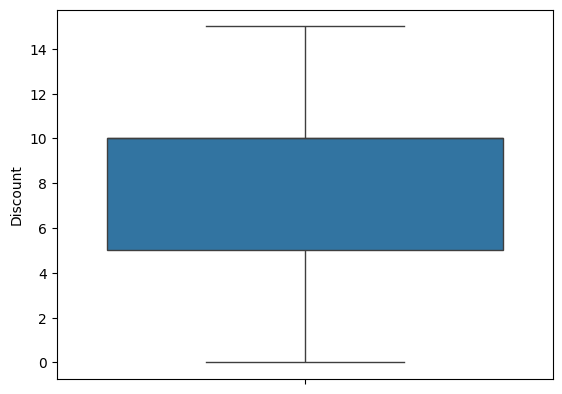

In [23]:
upper_limit_d=df['Discount'].quantile(0.83)
print(f"\nUpper limit for dis: {upper_limit_uo:.2f}")
df['Discount']=np.where(df['Discount']>upper_limit_d,upper_limit_d,df['Discount'])
print('Outliers removed')
sns.boxplot(df['Discount'])
plt.show()

<Axes: xlabel='Demand', ylabel='count'>

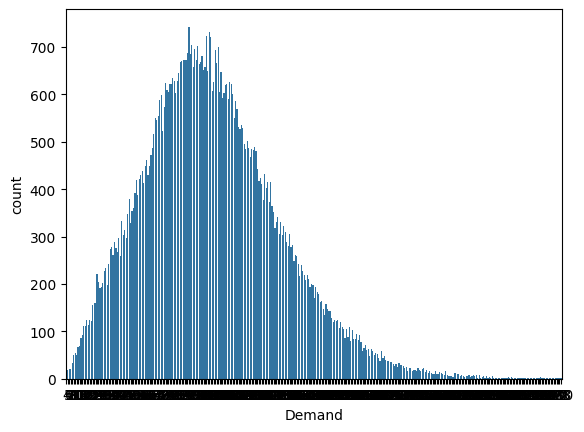

In [24]:
sns.countplot(x='Demand',data=df)

In [25]:
df['Price'].unique()

array([ 72.72,  80.16,  62.94, ...,  88.42,   8.05, 120.56],
      shape=(11519,))

In [26]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder, OneHotEncoder
from sklearn.compose import ColumnTransformer
df['Date'] = pd.to_datetime(df['Date'], errors='coerce')
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month
df['Day'] = df['Date'].dt.day
df.drop('Date', axis=1, inplace=True)

# Step 2: Define which columns to encode
label_cols = ['Store ID', 'Product ID', 'Seasonality']          # Label Encode
onehot_cols = ['Category', 'Region', 'Weather Condition']       # One-Hot Encode

# Step 3: Apply Label Encoding (for ordinal/high-cardinality columns)
le = LabelEncoder()
for col in label_cols:
    df[col] = le.fit_transform(df[col])

# Step 4: Apply One-Hot Encoding (for nominal columns)
ct = ColumnTransformer(
    transformers=[
        ('onehot', OneHotEncoder(drop='first', sparse_output=False), onehot_cols)
    ],
    remainder='passthrough'  # Keeps other columns, including Promotion & Epidemic
)

# Apply transformation
df_encoded = pd.DataFrame(ct.fit_transform(df))

# Step 5: Restore proper column names
onehot_feature_names = ct.named_transformers_['onehot'].get_feature_names_out(onehot_cols)
other_cols = [c for c in df.columns if c not in onehot_cols]
df_encoded.columns = list(onehot_feature_names) + other_cols

# Step 6: Reorder columns — move Year, Month, Day to the front
cols = df_encoded.columns.tolist()
date_cols = ['Year', 'Month', 'Day']
date_cols = [c for c in date_cols if c in cols]
new_order = date_cols + [c for c in cols if c not in date_cols]
df_encoded = df_encoded[new_order]

print(" Encoding complete & columns reordered!")
print("Final columns:", df_encoded.columns.tolist())

 Encoding complete & columns reordered!
Final columns: ['Year', 'Month', 'Day', 'Category_Electronics', 'Category_Furniture', 'Category_Groceries', 'Category_Toys', 'Region_North', 'Region_South', 'Region_West', 'Weather Condition_Rainy', 'Weather Condition_Snowy', 'Weather Condition_Sunny', 'Store ID', 'Product ID', 'Inventory Level', 'Units Sold', 'Units Ordered', 'Price', 'Discount', 'Promotion', 'Competitor Pricing', 'Seasonality', 'Epidemic', 'Demand']


In [27]:
df_encoded.head()

,Year,Month,Day,Category_Electronics,Category_Furniture,Category_Groceries,Category_Toys,Region_North,Region_South,Region_West,...,Inventory Level,Units Sold,Units Ordered,Price,Discount,Promotion,Competitor Pricing,Seasonality,Epidemic,Demand
0,2022.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,195.0,102.0,252.0,72.72,5.0,0.0,85.73,3.0,0.0,115.0
1,2022.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,117.0,117.0,249.0,80.16,15.0,1.0,92.02,3.0,0.0,229.0
2,2022.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,247.0,114.0,300.0,62.94,10.0,1.0,60.08,3.0,0.0,157.0
3,2022.0,1.0,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,...,139.0,45.0,102.0,87.63,10.0,0.0,85.19,3.0,0.0,52.0
4,2022.0,1.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,...,152.0,65.0,271.0,54.41,0.0,0.0,51.63,3.0,0.0,59.0


In [28]:
# save cleaned dataframe to CSV for deployment
# replace df_encoded with the exact variable name you used if different
df_encoded.to_csv("data.csv", index=False)
print("Saved data.csv with shape:", df_encoded.shape)


Saved data.csv with shape: (76000, 25)


<Axes: >

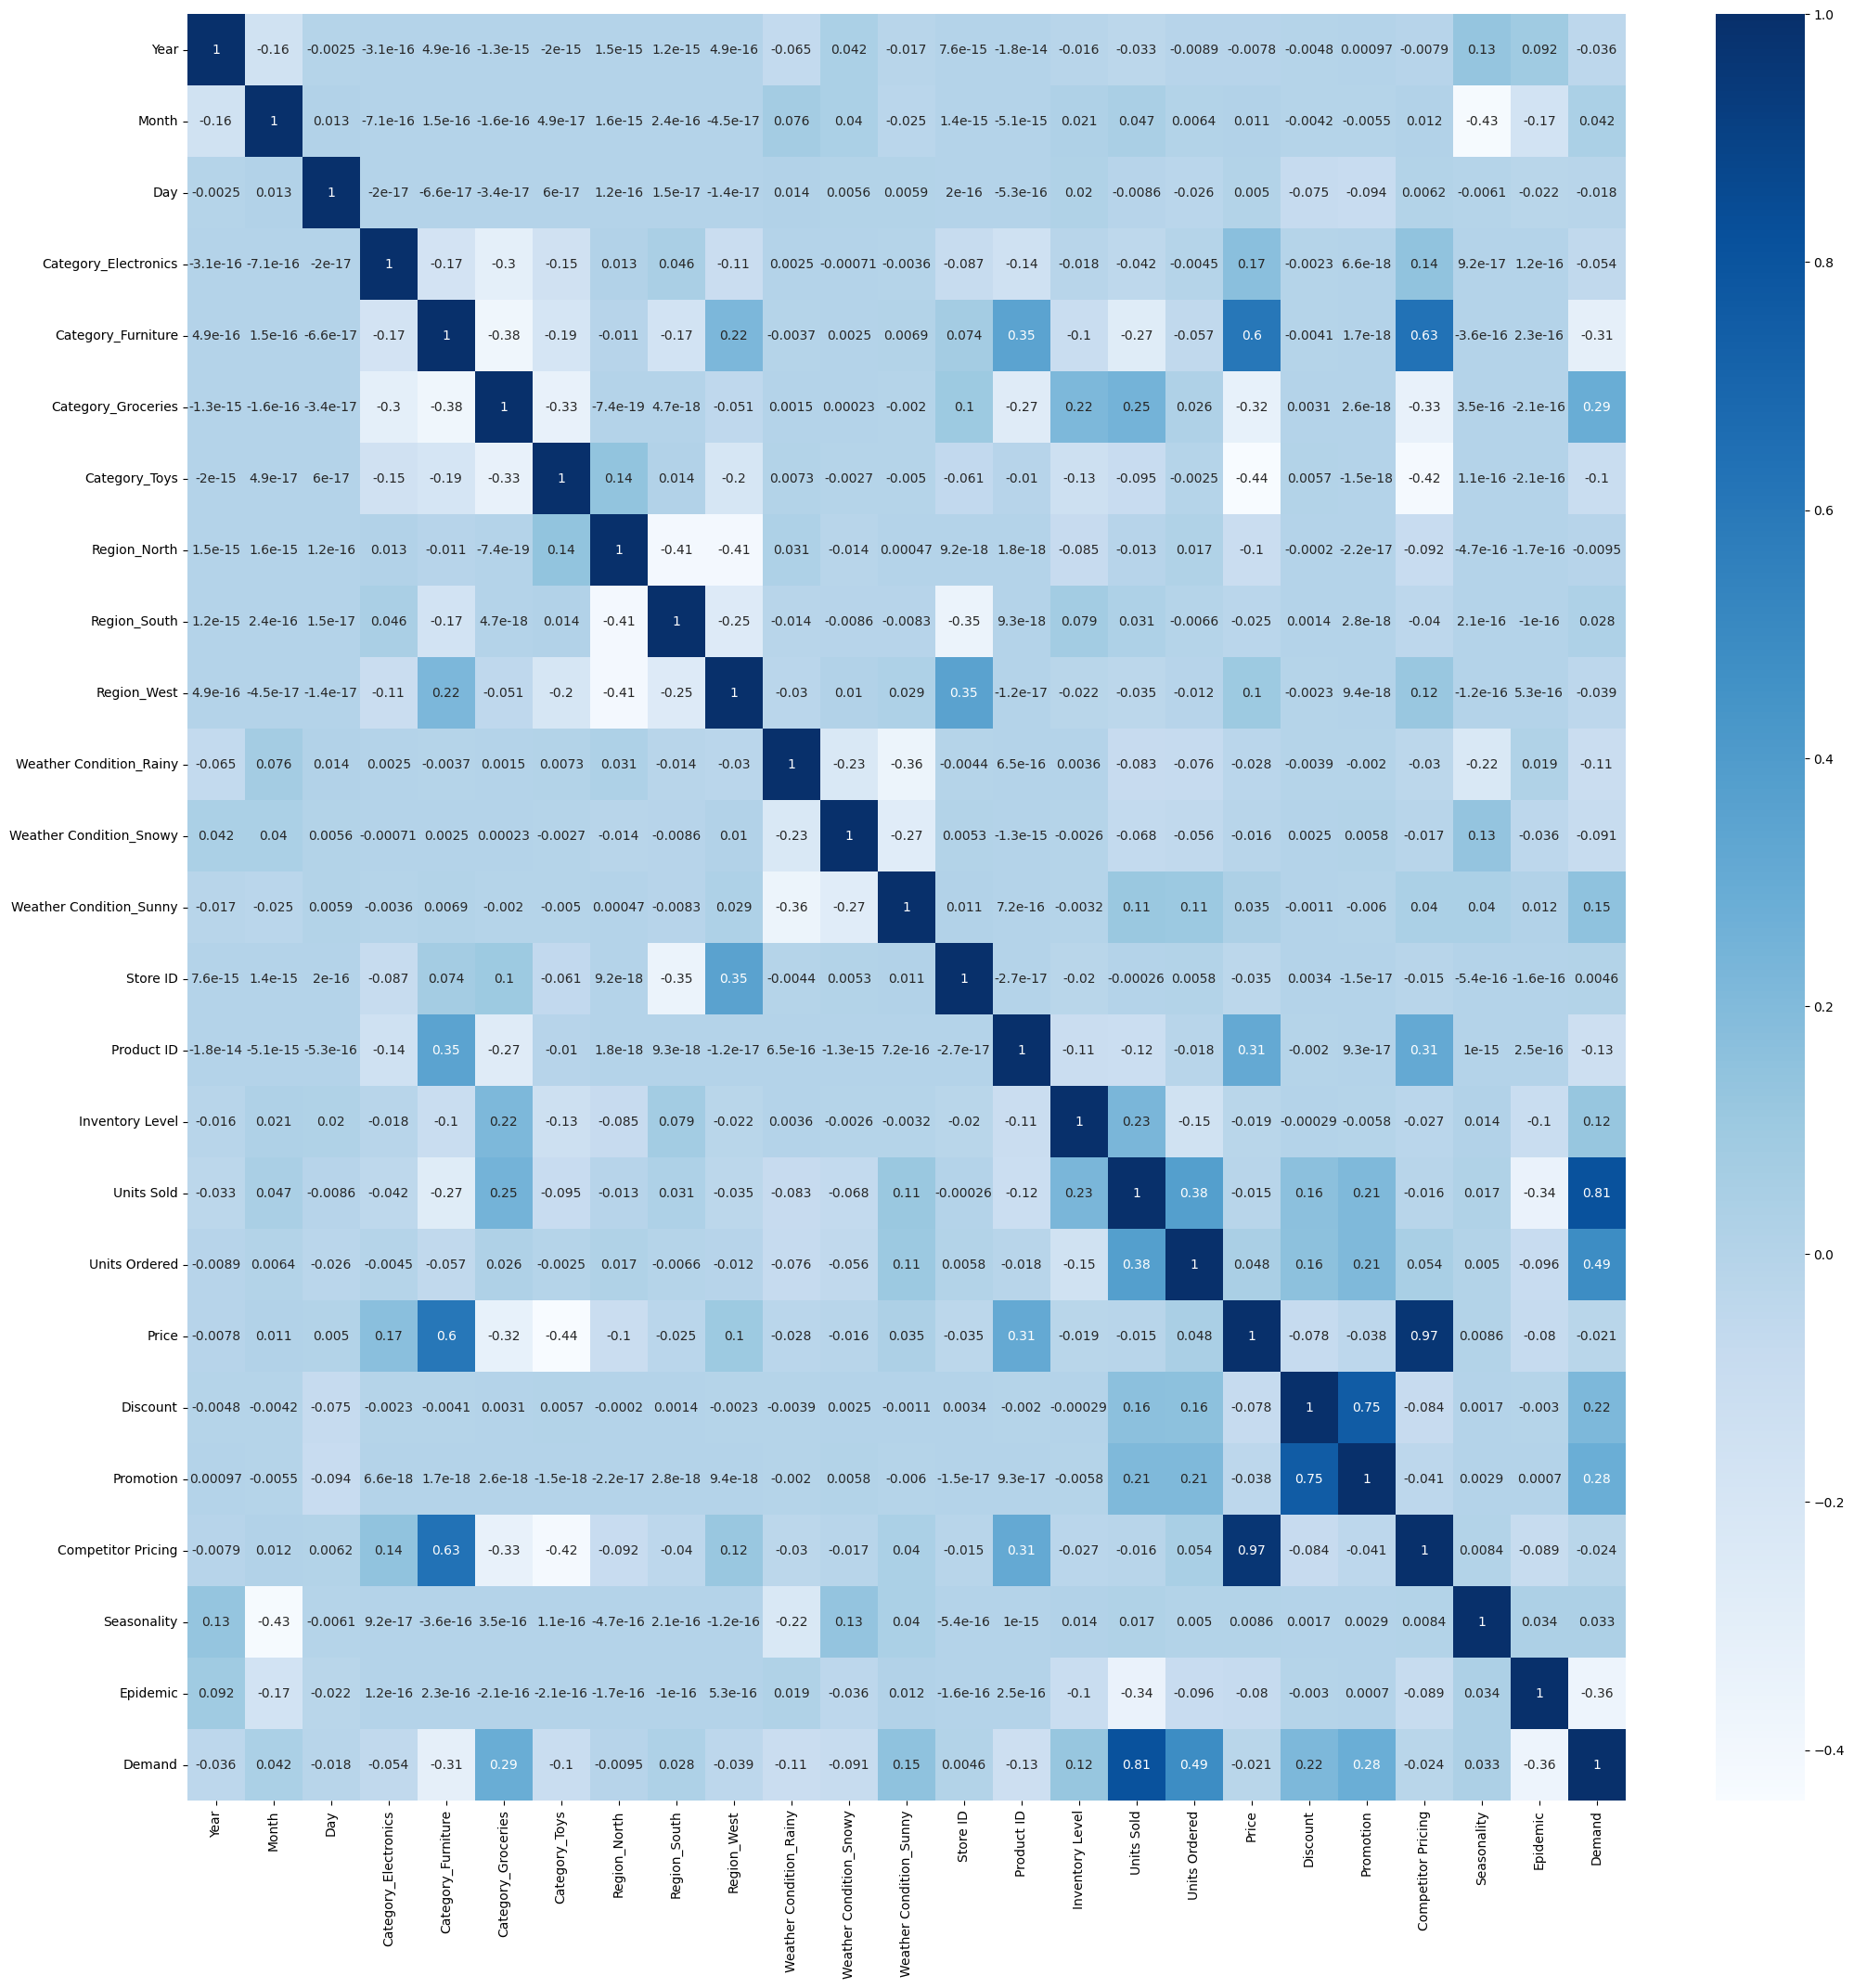

In [29]:
plt.figure(figsize=(25,25))
sns.heatmap(df_encoded.corr(),annot=True,cmap='Blues')

In [30]:
from sklearn.model_selection import train_test_split
x=df_encoded.drop('Demand',axis=1)
y=df_encoded['Demand']
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.25,random_state=42)
x_train.shape,x_test.shape,y_train.shape,y_test.shape

((57000, 24), (19000, 24), (57000,), (19000,))

In [31]:
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
x_train=scaler.fit_transform(x_train)
x_test=scaler.transform(x_test)

In [32]:
x_train

array([[-0.97913559,  0.7603116 , -0.19665235, ...,  0.6618555 ,
        -1.37895388, -0.50235636],
       [ 0.77206392, -1.21407387, -0.76575047, ...,  0.70513209,
         1.2759558 ,  1.99061878],
       [-0.97913559, -0.9320188 , -0.08283273, ..., -0.92825002,
        -0.49398398, -0.50235636],
       ...,
       [ 0.77206392,  0.19620146, -1.44866821, ...,  0.8136945 ,
         0.39098591, -0.50235636],
       [-0.97913559, -1.49612894, -0.76575047, ..., -1.38203597,
         1.2759558 , -0.50235636],
       [-0.97913559, -0.0858536 , -0.99338972, ..., -0.92058388,
         0.39098591, -0.50235636]], shape=(57000, 24))

In [33]:
x_test

array([[ 0.77206392, -0.0858536 ,  0.71390464, ...,  0.01295396,
         0.39098591, -0.50235636],
       [ 0.77206392,  0.7603116 , -1.33484859, ..., -0.9151434 ,
        -1.37895388, -0.50235636],
       [ 0.77206392,  1.6064768 ,  0.71390464, ...,  0.53400409,
         1.2759558 , -0.50235636],
       ...,
       [-0.97913559,  0.7603116 , -0.19665235, ...,  2.61177742,
        -1.37895388, -0.50235636],
       [-0.97913559,  1.6064768 , -0.4242916 , ...,  0.3576829 ,
         1.2759558 , -0.50235636],
       [ 0.77206392, -0.0858536 ,  0.82772426, ...,  1.99403255,
         0.39098591, -0.50235636]], shape=(19000, 24))

In [34]:
#model training
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(x_train,y_train)
reg.coef_

array([-1.62483470e-01,  2.96713559e-01, -9.08661492e-04, -2.78247908e+00,
       -9.06636087e+00,  4.06109580e+00, -5.75083906e-01, -2.30467448e-02,
       -7.02423518e-01,  1.45911105e-01, -1.22305980e+00, -1.97332105e+00,
        1.91188691e+00, -5.97194538e-03, -6.79202081e-01, -1.52240349e+00,
        2.75099645e+01,  8.93344307e+00,  3.20922430e+00,  6.38312042e-01,
        5.38292959e+00,  2.63616945e+00,  1.34081471e+00, -6.54714455e+00])

In [35]:
reg.intercept_

np.float64(104.24449122807019)

In [36]:
#prediction
y_pred=reg.predict(x_test)

In [37]:
#metrics
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
mse=mean_squared_error(y_test,y_pred)
mae=mean_absolute_error(y_test,y_pred)
score=r2_score(y_test,y_pred)
print(mse)
print(mae)
print(score)

543.5279188943657
17.12656757056447
0.7550633377033004


Part-2

*** HYPERPARAMETER TUNING ***

In [38]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error
# Create the Ridge model
ridge = Ridge(random_state=42)
# Define a small parameter grid for fast execution
param_grid = {
    'alpha': [0.001, 0.01, 0.1, 1, 10, 100]
}
# Initialize GridSearchCV
grid_ridge = GridSearchCV(
    estimator=ridge,
    param_grid=param_grid,
    cv=5,          # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1
)
# Fit on training data
grid_ridge.fit(x_train, y_train)
# Get the best model and alpha
best_ridge1 = grid_ridge.best_estimator_
best_alpha = grid_ridge.best_params_['alpha']
# Predict on test data
y_pred = best_ridge1.predict(x_test)
# Evaluate the model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
# Display results
print("Best Alpha Value:", best_alpha)
print("Best Cross-Validation R2 Score:", grid_ridge.best_score_)
print("Test R2 Score:", r2)
print("Test Mean Squared Error (MSE):", mse)

Best Alpha Value: 10
Best Cross-Validation R2 Score: 0.7514454510289523
Test R2 Score: 0.7550627461386351
Test Mean Squared Error (MSE): 543.5292316088788


In [39]:
from sklearn.linear_model import Lasso
# Create the Lasso model
lasso = Lasso(random_state=42, max_iter=10000)  # max_iter increased for convergence
# Define a small parameter grid for fast execution
param_grid = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10]
}
# Initialize GridSearchCV
grid_lasso = GridSearchCV(
    estimator=lasso,
    param_grid=param_grid,
    cv=5,          # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1
)
# Fit on training data
grid_lasso.fit(x_train, y_train)
# Get the best model and alpha
best_lasso1 = grid_lasso.best_estimator_
best_alpha = grid_lasso.best_params_['alpha']
# Predict on test data
y_pred = best_lasso1.predict(x_test)
# Evaluate performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
# Display results
print("Best Alpha Value:", best_alpha)
print("Best Cross-Validation R2 Score:", grid_lasso.best_score_)
print("Test R2 Score:", r2)
print("Test Mean Squared Error (MSE):", mse)

Best Alpha Value: 0.01
Best Cross-Validation R2 Score: 0.7514485996945572
Test R2 Score: 0.7550741626870516
Test Mean Squared Error (MSE): 543.5038976603241


In [40]:
from sklearn.tree import DecisionTreeRegressor
# Create the Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
# Define a small parameter grid for fast execution
param_grid = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# Initialize GridSearchCV
grid_dt = GridSearchCV(
    estimator=dt,
    param_grid=param_grid,
    cv=5,           # 5-fold cross-validation
    scoring='r2',
    n_jobs=-1
)
# Fit on training data
grid_dt.fit(x_train, y_train)
# Get best model and parameters
best_dt1 = grid_dt.best_estimator_
best_params = grid_dt.best_params_
# Predict on test data
y_pred = best_dt1.predict(x_test)
# Evaluate performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
# Display results
print("Best Parameters:", best_params)
print("Best Cross-Validation R2 Score:", grid_dt.best_score_)
print("Test R2 Score:", r2)
print("Test Mean Squared Error (MSE):", mse)

Best Parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}
Best Cross-Validation R2 Score: 0.8233769289478354
Test R2 Score: 0.8237142965305443
Test Mean Squared Error (MSE): 391.18766720809367


In [41]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
# Create Random Forest Regressor
rf = RandomForestRegressor(random_state=42)
# Smaller parameter grid for faster execution
param_dist = {
    'n_estimators': [30, 50, 80],      # Fewer trees = faster
    'max_depth': [None, 5, 10],        # Limit depth for simpler models
    'min_samples_split': [2, 5],       # Control node splits
    'min_samples_leaf': [1, 2]         # Minimum leaf size
}
# Use RandomizedSearchCV for speed
random_rf = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=6,         # Only 6 random combinations (very fast)
    cv=3,             # 3-fold cross-validation
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
# Fit on training data
random_rf.fit(x_train, y_train)
# Get best model and parameters
best_rf = random_rf.best_estimator_
best_params = random_rf.best_params_
# Predict on test data
y_pred = best_rf.predict(x_test)
# Evaluate model
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
# Display results
print("Best Parameters:", best_params)
print("Best Cross-Validation R2 Score:", random_rf.best_score_)
print("Test R2 Score:", r2)
print("Test Mean Squared Error (MSE):", mse)

Best Parameters: {'n_estimators': 80, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_depth': 10}
Best Cross-Validation R2 Score: 0.8423032401421123
Test R2 Score: 0.8415251360405785
Test Mean Squared Error (MSE): 351.66443519424365


In [42]:
from sklearn.ensemble import AdaBoostRegressor
# Create AdaBoost Regressor
ada = AdaBoostRegressor(random_state=42)
# Define small parameter grid for fast execution
param_dist = {
    'n_estimators': [30, 50, 80, 100],   # number of weak learners
    'learning_rate': [0.001, 0.01, 0.1, 0.5, 1.0]  # step size
}
# Initialize RandomizedSearchCV
random_ada = RandomizedSearchCV(
    estimator=ada,
    param_distributions=param_dist,
    n_iter=6,         # try 6 random combinations -> fast
    cv=3,             # 3-fold CV for speed
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
# Fit on training data
random_ada.fit(x_train, y_train)
# Get best model and parameters
best_ada = random_ada.best_estimator_
best_params = random_ada.best_params_
# Predict on test data
y_pred = best_ada.predict(x_test)
# Evaluate performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
# Display results
print("Best Parameters:", best_params)
print("Best Cross-Validation R2 Score:", random_ada.best_score_)
print("Test R2 Score:", r2)
print("Test Mean Squared Error (MSE):", mse)

Best Parameters: {'n_estimators': 30, 'learning_rate': 0.1}
Best Cross-Validation R2 Score: 0.7303403457512925
Test R2 Score: 0.7307241522966585
Test Mean Squared Error (MSE): 597.5379093450047


In [43]:
from sklearn.ensemble import GradientBoostingRegressor
# Create Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)
# Small parameter grid for fast execution
param_dist = {
    'n_estimators': [50, 80, 100],          # number of boosting stages
    'learning_rate': [0.01, 0.05, 0.1],     # step size shrinkage
    'max_depth': [2, 3, 5],                 # depth of individual trees
    'min_samples_split': [2, 5],            # min samples to split a node
    'min_samples_leaf': [1, 2]              # min samples at leaf
}
# Initialize RandomizedSearchCV
random_gbr = RandomizedSearchCV(
    estimator=gbr,
    param_distributions=param_dist,
    n_iter=6,          # 6 random combos -> fast
    cv=3,              # 3-fold CV for speed
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
# Fit on training data
random_gbr.fit(x_train, y_train)
# Get best model and parameters
best_gbr = random_gbr.best_estimator_
best_params = random_gbr.best_params_
# Predict on test data
y_pred = best_gbr.predict(x_test)
# Evaluate model performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
# Display results
print("Best Parameters:", best_params)
print("Best Cross-Validation R2 Score:", random_gbr.best_score_)
print("Test R2 Score:", r2)
print("Test Mean Squared Error (MSE):", mse)

Best Parameters: {'n_estimators': 100, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_depth': 5, 'learning_rate': 0.05}
Best Cross-Validation R2 Score: 0.8449527394789428
Test R2 Score: 0.8447141181867259
Test Mean Squared Error (MSE): 344.5879084994069


In [44]:
# Create Decision Tree Regressor
dt = DecisionTreeRegressor(random_state=42)
# Small parameter grid for fast execution
param_dist = {
    'max_depth': [None, 5, 10, 15],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['squared_error', 'friedman_mse']
}
# Initialize RandomizedSearchCV
random_dt = RandomizedSearchCV(
    estimator=dt,
    param_distributions=param_dist,
    n_iter=6,          # Only 6 random combinations → fast
    cv=3,              # 3-fold cross-validation
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
# Fit on training data
random_dt.fit(x_train, y_train)
# Get best model and parameters
best_dt = random_dt.best_estimator_
best_params = random_dt.best_params_
# Predict on test data
y_pred = best_dt.predict(x_test)
# Evaluate model performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
# Display results
print("Best Parameters:", best_params)
print("Best Cross-Validation R2 Score:", random_dt.best_score_)
print("Test R2 Score:", r2)
print("Test Mean Squared Error (MSE):", mse)

Best Parameters: {'min_samples_split': 10, 'min_samples_leaf': 4, 'max_depth': 10, 'criterion': 'friedman_mse'}
Best Cross-Validation R2 Score: 0.8209680730812717
Test R2 Score: 0.8249903278540363
Test Mean Squared Error (MSE): 388.3560835521464


In [45]:
# Create Ridge Regressor
ridge = Ridge(random_state=42)
# Small parameter grid for fast execution
param_dist = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10, 100],
    'solver': ['auto', 'saga', 'lbfgs']
}
# Initialize RandomizedSearchCV
random_ridge = RandomizedSearchCV(
    estimator=ridge,
    param_distributions=param_dist,
    n_iter=6,          # 6 random combinations → fast
    cv=3,              # 3-fold cross-validation
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
# Fit on training data
random_ridge.fit(x_train, y_train)
# Get best model and parameters
best_ridge = random_ridge.best_estimator_
best_params = random_ridge.best_params_
# Predict on test data
y_pred = best_ridge.predict(x_test)
# Evaluate performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
# Display results
print("Best Parameters:", best_params)
print("Best Cross-Validation R2 Score:", random_ridge.best_score_)
print("Test R2 Score:", r2)
print("Test Mean Squared Error (MSE):", mse)

Best Parameters: {'solver': 'auto', 'alpha': 10}
Best Cross-Validation R2 Score: 0.7514128042708882
Test R2 Score: 0.7550627461386351
Test Mean Squared Error (MSE): 543.5292316088788


c:\Users\sweth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
9 fits failed out of a total of 18.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
9 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\sweth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\sweth\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\sweth\AppData\

In [46]:
from sklearn.linear_model import Lasso
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import r2_score, mean_squared_error
# Create Lasso Regressor
lasso = Lasso(random_state=42, max_iter=10000)
# Small parameter grid for fast execution
param_dist = {
    'alpha': [0.0001, 0.001, 0.01, 0.1, 1, 10],
    'selection': ['cyclic', 'random']
}
# Initialize RandomizedSearchCV
random_lasso = RandomizedSearchCV(
    estimator=lasso,
    param_distributions=param_dist,
    n_iter=6,          # Try only 6 random combinations → very fast
    cv=3,              # 3-fold cross-validation
    scoring='r2',
    random_state=42,
    n_jobs=-1
)
# Fit on training data
random_lasso.fit(x_train, y_train)
# Get best model and parameters
best_lasso = random_lasso.best_estimator_
best_params = random_lasso.best_params_
# Predict on test data
y_pred = best_lasso.predict(x_test)
# Evaluate model performance
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
# Display results
print("Best Parameters:", best_params)
print("Best Cross-Validation R2 Score:", random_lasso.best_score_)
print("Test R2 Score:", r2)
print("Test Mean Squared Error (MSE):", mse)

Best Parameters: {'selection': 'random', 'alpha': 0.01}
Best Cross-Validation R2 Score: 0.7514152783520806
Test R2 Score: 0.7550733737275755
Test Mean Squared Error (MSE): 543.5056484047743


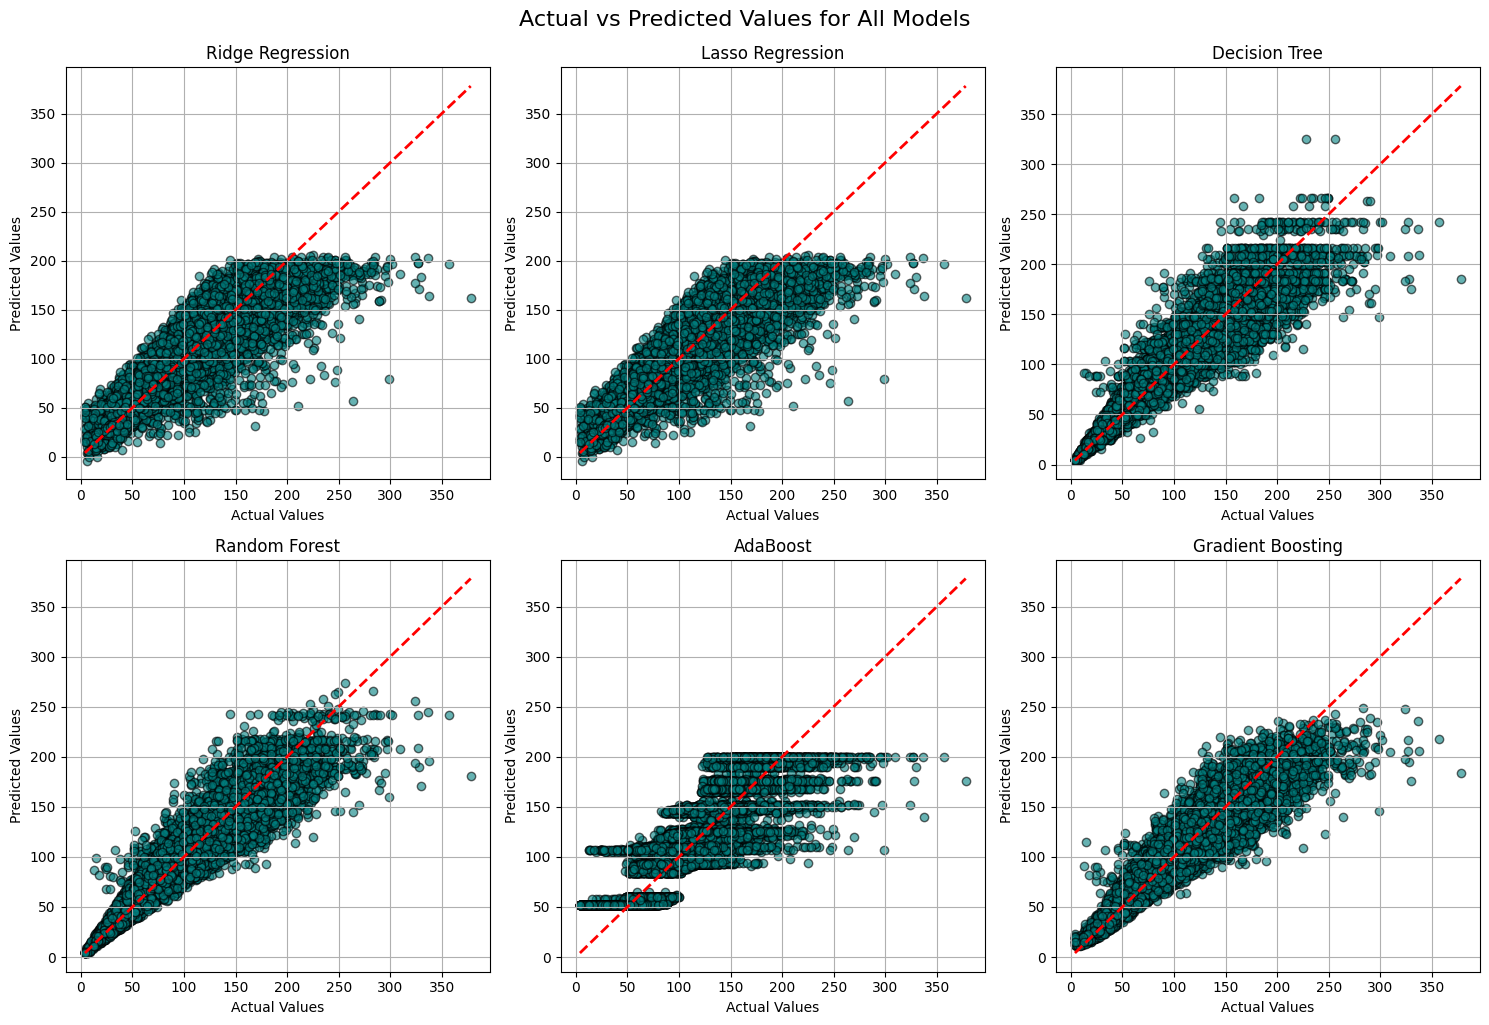

In [47]:
y_predl= best_lasso.predict(x_test)
y_predr = best_ridge.predict(x_test)
y_predd = best_dt.predict(x_test)
y_predg = best_gbr.predict(x_test)
y_preda= best_ada.predict(x_test)
y_predrf = best_rf.predict(x_test)
# List of models and their predictions
models = [
    ("Ridge Regression", y_predr),
    ("Lasso Regression", y_predl),
    ("Decision Tree", y_predd),
    ("Random Forest", y_predrf),
    ("AdaBoost", y_preda),
    ("Gradient Boosting", y_predg)
]

# Create subplots (2 rows x 3 columns)
plt.figure(figsize=(15, 10))

for i, (name, y_pred) in enumerate(models, 1):
    plt.subplot(2, 3, i)
    plt.scatter(y_test, y_pred, alpha=0.6, color='teal', edgecolors='k')
    plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
    plt.title(name)
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.grid(True)

plt.tight_layout()
plt.suptitle("Actual vs Predicted Values for All Models", fontsize=16, y=1.02)
plt.show()


In [49]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(x_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [50]:
import pickle

# Save model
pickle.dump(model, open('model.pkl', 'wb'))

# Save scaler (if used)
pickle.dump(scaler, open('scaler.pkl', 'wb'))